In [1]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn 
import torch.optim as optim 
import matplotlib.pyplot as plt 

In [23]:
torch.manual_seed(42)
x = torch.randn(200,2)
y = (x[:,0] + x[:, 1]>0).float().view(-1,1)

In [24]:
class SimpleNN(nn.Module): 
    def __init__(self, a_fn):
        super().__init__()
        self.fc1 = nn.Linear(2,8)
        self.fc2 = nn.Linear(8,1) 
        self.a = a_fn
    
    def forward(self, x): 
        x = self.a(self.fc1(x))
        x = torch.sigmoid(self.fc2(x)) 
        return x 

def train(l_r, a_fn, epoch = 50): 
    model = SimpleNN(a_fn)
    cr = nn.BCELoss()
    opt = optim.SGD(model.parameters(), lr = l_r) 
    
    losses = []
    
    for _ in range(epoch): 
        opt.zero_grad()
        
        ops = model(x)
        loss = cr(ops, y)
        loss.backward()
        opt.step()
        
        losses.append(loss.item())
    
    return losses
    

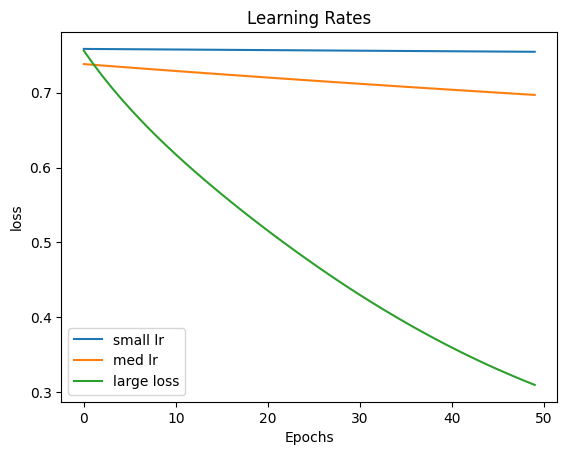

In [26]:
l_s = 0.001 
l_m = 0.01
l_l = 0.1

loss_s = train(l_s, nn.ReLU())
loss_m = train(l_m, nn.ReLU()) 
loss_l = train(l_l, nn.ReLU())

plt.figure()
plt.title('Learning Rates')
plt.plot(loss_s, label="small lr")
plt.plot(loss_m, label="med lr")
plt.plot(loss_l, label="large loss")
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.show()

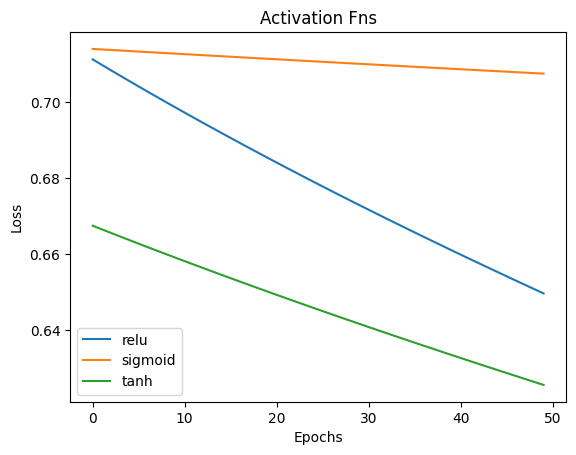

In [30]:
loss_relu = train(0.01, nn.ReLU())
loss_sigm = train(0.01, nn.Sigmoid())
loss_tanh = train(0.01, nn.Tanh())

plt.figure()
plt.title('Activation Fns')
plt.plot(loss_relu, label='relu')
plt.plot(loss_sigm, label='sigmoid')
plt.plot(loss_tanh, label='tanh')
plt.xlabel('Epochs') 
plt.ylabel('Loss')
plt.legend()
plt.show()